In [ ]:
project_path = "/content/drive/MyDrive/nlp_classification"

In [ ]:
import sys

sys.path.append(project_path)

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [154]:
import torch.nn as nn
import torch.optim as optim

from transformers import AutoTokenizer

In [ ]:
from importlib import reload

import core.utils
import core.nlp
import core.visualization
import core.baseline_training
import core.vectorization
import core.training_results
import core.nn_models
import core.nn_training

# For Goggle Colab
reload(core.utils)
reload(core.nlp)
reload(core.visualization)
reload(core.baseline_training)
reload(core.vectorization)
reload(core.training_results)
reload(core.nn_models)
reload(core.nn_training)

from core.utils import (
    init_random_seed,
    divide_data,
    get_device,
    count_parameters,
    free_memory,
    load_glove_fixed_vocab,
    count_trainable_parameters,
)
from core.nlp import tokenize_tiktoken, filter_tokens
from core.visualization import (
    plot_histogram_numeric,
    plot_metrics_heatmap,
)
from core.baseline_training import train_evaluate_model_cv
from core.vectorization import SequenceVectorizer

from core.nn_models import (
    RNNForCategoryClassification,
    CNNForCategoryClassification,
    LSTMForCategoryClassification,
    GloveCNNForCategoryClassification,
    BertTextClassifier,
)
from core.nn_training import cross_validate_model, cross_validate_transformer_model

In [158]:
SEED = 42

init_random_seed(SEED)

In [ ]:
def save_metrics_to_csv(metrics, metrics_file_name):
    data = metrics.model_dump()

    df = pd.DataFrame([data])
    df.to_csv(f"{project_path}/{metrics_file_name}.csv", encoding="utf-8", index=False)


def load_metrics_from_csv(metrics_file_name):
    df = pd.read_csv(f"{project_path}/{metrics_file_name}.csv")
    return df

In [ ]:
from typing import Optional
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


def plot_single_model_metrics_difference_heatmap(
    model_1_metrics: pd.DataFrame,
    model_2_metrics: pd.DataFrame,
    model_1_name: Optional[str] = None,
    model_2_name: Optional[str] = None,
    figsize: tuple[int, int] = (12, 6),
    annot_fontsize: int = 10,
    title: Optional[str] = None,
    lower_is_better_metrics: Optional[list[str]] = None,
) -> pd.DataFrame:
    """
    Сравнение двух моделей, где каждый DataFrame содержит ровно одну строку метрик.

    difference = model_2 - model_1

    Зеленый = улучшение
    Красный = ухудшение
    """

    if len(model_1_metrics) != 1 or len(model_2_metrics) != 1:
        raise ValueError(
            "Ожидается, что каждый DataFrame содержит ровно одну строку с метриками модели."
        )

    if list(model_1_metrics.columns) != list(model_2_metrics.columns):
        raise ValueError("У обоих DataFrame должны совпадать колонки и их порядок.")

    if model_1_name is None:
        model_1_name = str(model_1_metrics.index[0])

    if model_2_name is None:
        model_2_name = str(model_2_metrics.index[0])

    if lower_is_better_metrics is None:
        lower_is_better_patterns = [
            "time",
            "loss",
            "error",
            "cost",
            "latency",
            "duration",
            "mse",
            "mae",
            "rmse",
            "runtime",
            "seconds",
            "minutes",
        ]
        lower_is_better_metrics = [
            column
            for column in model_1_metrics.columns
            if any(pattern in column.lower() for pattern in lower_is_better_patterns)
        ]

    # Вычитание по значениям, а не по индексам
    difference = pd.DataFrame(
        [model_2_metrics.iloc[0].values - model_1_metrics.iloc[0].values],
        columns=model_1_metrics.columns,
        index=[f"{model_2_name} - {model_1_name}"],
    )

    # Дополнительные процентные изменения для временных метрик
    time_patterns = ["time", "duration", "runtime", "seconds", "minutes"]
    for column in model_1_metrics.columns:
        if any(pattern in column.lower() for pattern in time_patterns):
            pct_column_name = f"{column} Change (%)"

            base_value = model_1_metrics.iloc[0][column]
            diff_value = difference.iloc[0][column]

            with np.errstate(divide="ignore", invalid="ignore"):
                pct_change = (diff_value / base_value) * 100 if base_value != 0 else 0

            difference[pct_column_name] = [pct_change]

            if (
                column in lower_is_better_metrics
                and pct_column_name not in lower_is_better_metrics
            ):
                lower_is_better_metrics.append(pct_column_name)

    # Для визуализации: где меньше = лучше, инвертируем знак
    semantic_difference = difference.copy()
    for column in lower_is_better_metrics:
        if column in semantic_difference.columns:
            semantic_difference[column] = -semantic_difference[column]

    # Нормализация по колонкам
    normalized_difference = semantic_difference.copy().astype(float)

    for column in semantic_difference.columns:
        value = float(semantic_difference.iloc[0][column])

        if value > 0:
            normalized_difference.iloc[
                0, normalized_difference.columns.get_loc(column)
            ] = 1.0
        elif value < 0:
            normalized_difference.iloc[
                0, normalized_difference.columns.get_loc(column)
            ] = -1.0
        else:
            normalized_difference.iloc[
                0, normalized_difference.columns.get_loc(column)
            ] = 0.0

    cmap = LinearSegmentedColormap.from_list("rwg", ["#ff2700", "#ffffff", "#00b975"])

    if title is None:
        title = f"Metrics Difference: {model_2_name} - {model_1_name}"

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        normalized_difference,
        annot=difference,
        fmt=".3f",
        cmap=cmap,
        center=0,
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": annot_fontsize},
        cbar_kws={"label": "Improvement (Green) ← → Degradation (Red)"},
    )

    ax.set_title(title, pad=20, fontsize=14)
    ax.set_xlabel("Metrics")
    ax.set_ylabel("Model comparison")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(normalized_difference.index.tolist(), rotation=0)

    plt.tight_layout()
    plt.show()

    return difference

## 1. Загрузка и препроцессинг данных

In [ ]:
df = pd.read_csv(f"{project_path}/ecommerceDataset.csv", names=["Category", "Text"])

In [ ]:
df_preprocessed = df.copy()

df_preprocessed = df_preprocessed.drop_duplicates().reset_index(drop=True)

df_preprocessed = df_preprocessed.dropna().reset_index(drop=True)

category_dict = {
    "Electronics": 0,
    "Household": 1,
    "Books": 2,
    "Clothing & Accessories": 3,
}

df_preprocessed = df_preprocessed.replace({"Category": category_dict})

df_preprocessed["Text"] = df_preprocessed["Text"].apply(tokenize_tiktoken)

df_preprocessed["Text"] = df_preprocessed["Text"].map(
    lambda tokens: filter_tokens(
        tokens,
        remove_stopwords=True,
        remove_punctuation_tokens=False,
        lowercase_for_counting=True,
    )
)

/tmp/ipykernel_1040/1084455906.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_preprocessed = df_preprocessed.replace({'Category': category_dict})


In [ ]:
# Разделяем данные на признаки (X) и целевую переменную (y)
X, y = divide_data(df_preprocessed, "Category")

## 2. Baseline

In [ ]:
logistic_regression = LogisticRegression(
    random_state=SEED, max_iter=1000, solver="lbfgs"
)

In [68]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [ ]:
tfidf_vectorizer_preprocessor = Pipeline(
    [
        (
            "vectorizer",
            ColumnTransformer(
                [
                    (
                        "text_vectorizer",
                        TfidfVectorizer(
                            analyzer=lambda x: x, min_df=50, dtype=np.float32
                        ),
                        "Text",
                    )
                ],
                remainder="passthrough",
                verbose_feature_names_out=True,
            ),
        )
    ]
)


<Figure size 1500x600 with 0 Axes>

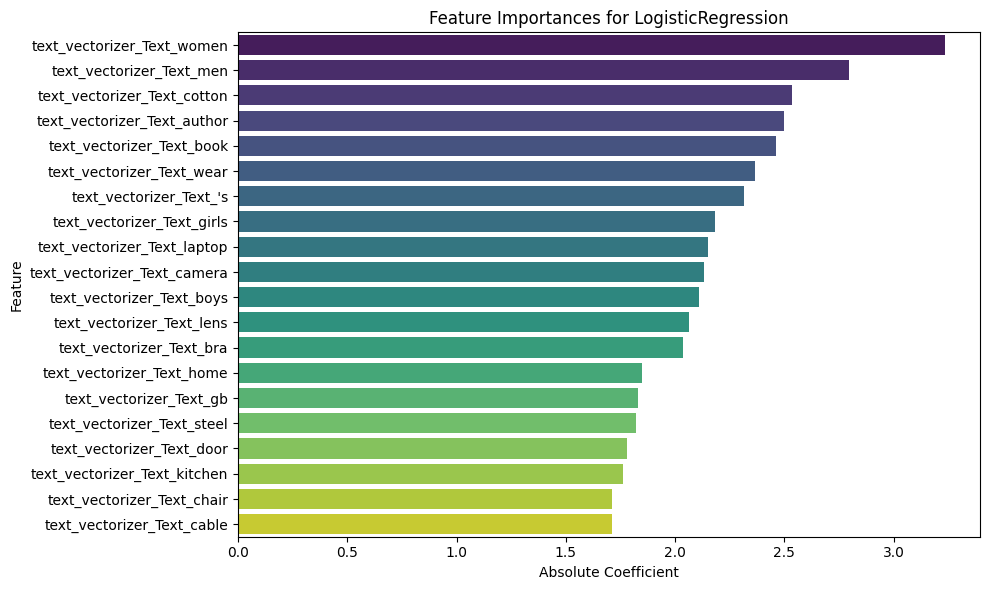

In [ ]:
baseline_metrics, baseline_pipeline = train_evaluate_model_cv(
    model=logistic_regression,
    model_name="LogisticRegression",
    X=X,
    y=y,
    preprocessor=tfidf_vectorizer_preprocessor,
    cv=cv,
    seed=SEED,
)

In [78]:
baseline_metrics.to_compact_dict()

{'ROC AUC': 0.9883041072393869,
 'F1 Score': 0.9418319482779113,
 'Precision': 0.9464029115171524,
 'Recall': 0.9377520092060482,
 'Accuracy': 0.9420904865871362,
 'Training Time (s)': 14.443501472473145}

In [ ]:
metrics_file_name = "baseline_metrics"

save_metrics_to_csv(baseline_metrics, metrics_file_name)

## 3. Препроцессинг перед использованием нейросетей

In [80]:
data_nn = df_preprocessed.copy()

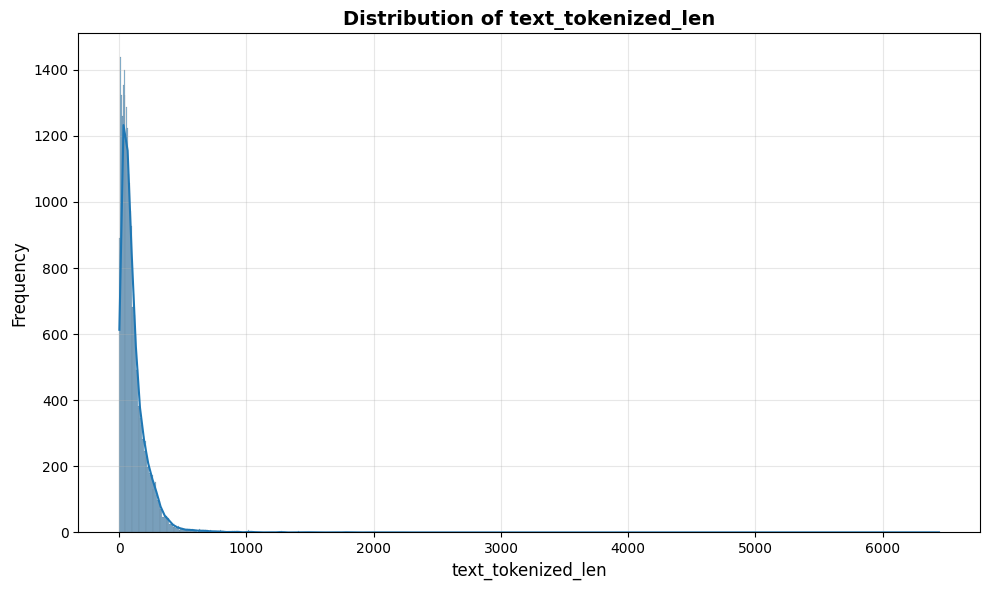

In [ ]:
data_nn["text_tokenized_len"] = data_nn["Text"].apply(len)

plot_histogram_numeric(data_nn, "text_tokenized_len", figsize=(10, 6))

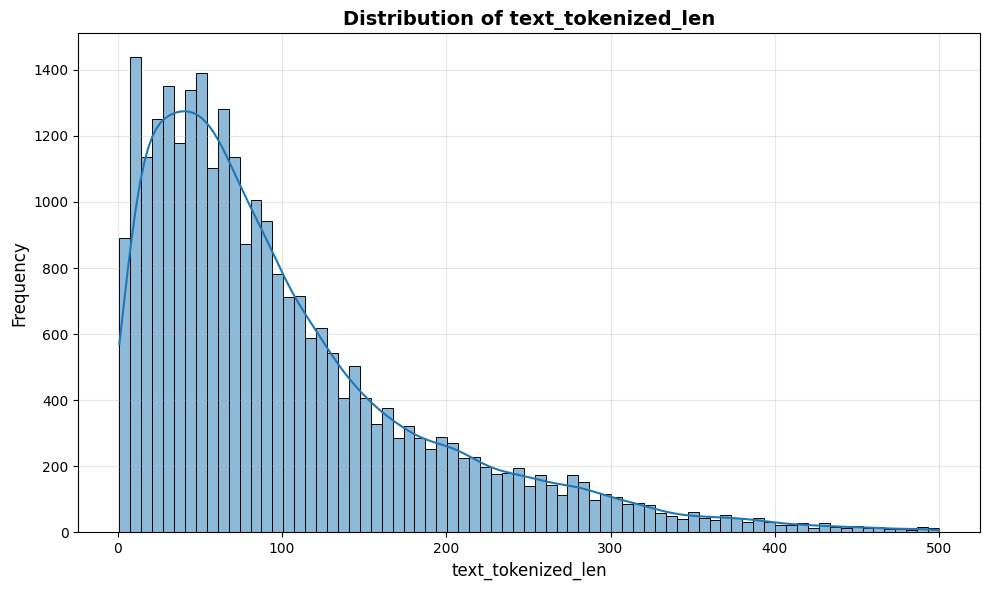

In [ ]:
max_len = 500

data_filtered = data_nn[data_nn["text_tokenized_len"] <= max_len]

plot_histogram_numeric(data_filtered, "text_tokenized_len", figsize=(10, 6))

In [ ]:
data_nn.drop(columns=["text_tokenized_len"], inplace=True)

Для максимально полного анализа текстов откажемся лишь от малозаметного хвоста распределения и будем анализировать только первые 500 токенов последовательностей

In [84]:
# Параметры для нейронных сетей
MAX_SEQUENCE_LENGTH = 500  # максимальная длина последовательности токенов

In [ ]:
vectorizer = SequenceVectorizer(max_length=MAX_SEQUENCE_LENGTH, pad_left=False)
input_vectorized = vectorizer.fit_transform(data_nn["Text"])

input_vectorized.shape

(27802, 500)

In [ ]:
basic_preprocessor = Pipeline([("vectorizer", vectorizer)])

basic_preprocessor

Pipeline(steps=[('vectorizer',
                 SequenceVectorizer(max_length=500, pad_left=False))])

## 4. RNN (Рекуррентная нейронная сеть)

RNN обрабатывает последовательности токенов слева направо, сохраняя информацию о предыдущих токенах. Используем Bidirectional RNN для анализа контекста в обе стороны

In [87]:
# Гиперпараметры для RNN модели

LEARNING_RATE = 1e-3
BATCH_SIZE = 256
RNN_UNITS = 8
EMBEDDING_DIM = 256

DROPOUT_RATE = 0.2
RECCURENT_DROPOUT_RATE = 0

REGULARIZATION_STRENGTH = 1e-4

In [88]:
device = get_device()

device

device(type='cuda')

In [ ]:
rnn_model = RNNForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    rnn_units=RNN_UNITS,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECCURENT_DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id,
)

rnn_model

RNNForCategoryClassification(
  (embedding): Embedding(31068, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (rnn): RNN(256, 8, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=16, out_features=4, bias=True)
)

In [90]:
print(f"Рекуррентная модель содержит число параметров: {count_parameters(rnn_model)}")

Рекуррентная модель содержит число параметров: 7957732


Определим функцию потерь и оптимизатор

In [91]:
criterion = nn.CrossEntropyLoss()

optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}

Запускаем обучение модели


🌀 Fold 1/3


Training fold 1:   0%|          | 1/500 [00:01<13:33,  1.63s/it]

  Epoch 1/500 | Train Loss: 1.3667 | Val Loss: 1.3345


Training fold 1:   0%|          | 2/500 [00:03<13:34,  1.64s/it]

  Epoch 2/500 | Train Loss: 1.3256 | Val Loss: 1.3191


...

  Epoch 59/500 | Train Loss: 0.4663 | Val Loss: 0.6760


Training fold 1:  12%|█▏        | 60/500 [01:32<11:11,  1.53s/it]

  Epoch 60/500 | Train Loss: 0.4673 | Val Loss: 0.6754


Training fold 1:  12%|█▏        | 60/500 [01:33<11:26,  1.56s/it]


  Epoch 61/500 | Train Loss: 0.4568 | Val Loss: 0.6992
  Early stopping on epoch 61 (best epoch: 51, best val loss: 0.6686)


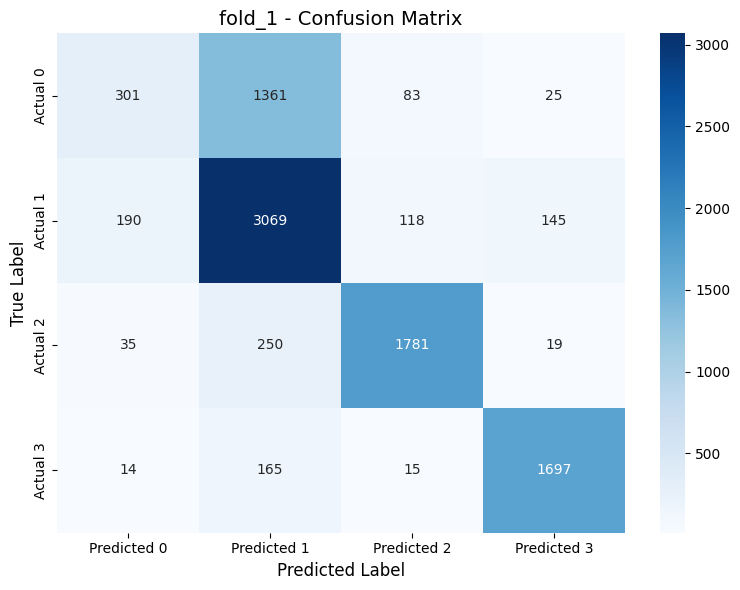


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8813
 F1 Score 0.6914
Precision 0.7456
   Recall 0.6983
 Accuracy 0.7389


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.557407 0.170056
    1   0.633437 0.871380
    2   0.891838 0.854197
    3   0.899788 0.897409


🌀 Fold 2/3


Training fold 2:   0%|          | 1/500 [00:01<13:42,  1.65s/it]

  Epoch 1/500 | Train Loss: 1.3631 | Val Loss: 1.3244


Training fold 2:   0%|          | 2/500 [00:03<13:40,  1.65s/it]

  Epoch 2/500 | Train Loss: 1.3251 | Val Loss: 1.3073


...

  Epoch 59/500 | Train Loss: 0.2886 | Val Loss: 0.6107


Training fold 2:  12%|█▏        | 60/500 [01:33<11:25,  1.56s/it]

  Epoch 60/500 | Train Loss: 0.2781 | Val Loss: 0.5980


Training fold 2:  12%|█▏        | 60/500 [01:35<11:40,  1.59s/it]


  Epoch 61/500 | Train Loss: 0.6181 | Val Loss: 0.8300
  Early stopping on epoch 61 (best epoch: 51, best val loss: 0.5621)


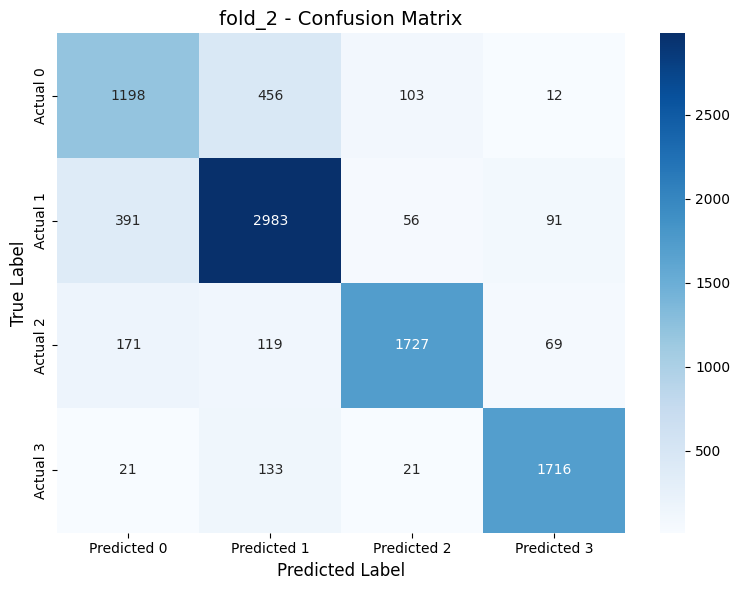


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9327
 F1 Score 0.8188
Precision 0.8238
   Recall 0.8149
 Accuracy 0.8227


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.672656 0.677219
    1   0.808182 0.847202
    2   0.905611 0.827900
    3   0.908898 0.907456


🌀 Fold 3/3


Training fold 3:   0%|          | 1/500 [00:01<13:21,  1.61s/it]

  Epoch 1/500 | Train Loss: 1.3713 | Val Loss: 1.3090


Training fold 3:   0%|          | 2/500 [00:03<12:55,  1.56s/it]

  Epoch 2/500 | Train Loss: 1.3277 | Val Loss: 1.2916


...

  Epoch 65/500 | Train Loss: 0.2176 | Val Loss: 0.5715


Training fold 3:  13%|█▎        | 66/500 [01:42<11:01,  1.52s/it]

  Epoch 66/500 | Train Loss: 0.2117 | Val Loss: 0.5872


Training fold 3:  13%|█▎        | 66/500 [01:44<11:26,  1.58s/it]


  Epoch 67/500 | Train Loss: 0.2277 | Val Loss: 0.5969
  Early stopping on epoch 67 (best epoch: 57, best val loss: 0.5476)


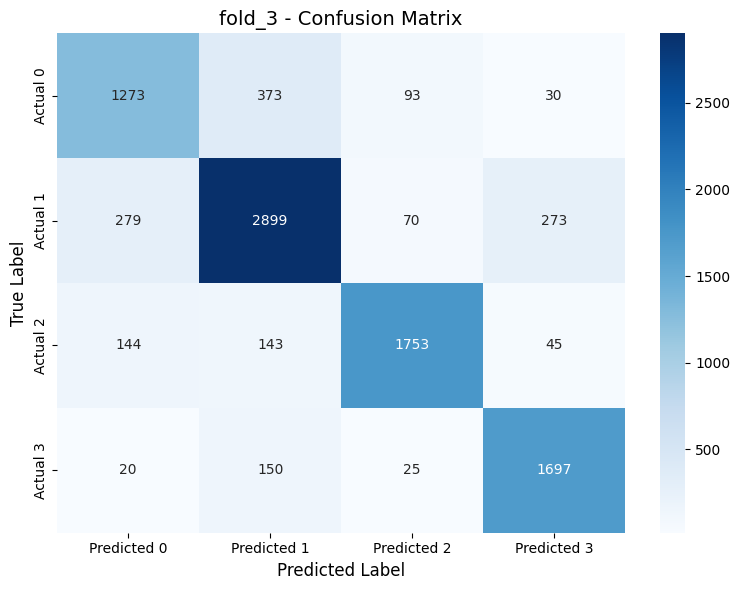


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9337
 F1 Score 0.8204
Precision 0.8220
   Recall 0.8202
 Accuracy 0.8225


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.741841 0.719616
    1   0.813184 0.823346
    2   0.903143 0.840767
    3   0.829829 0.896934



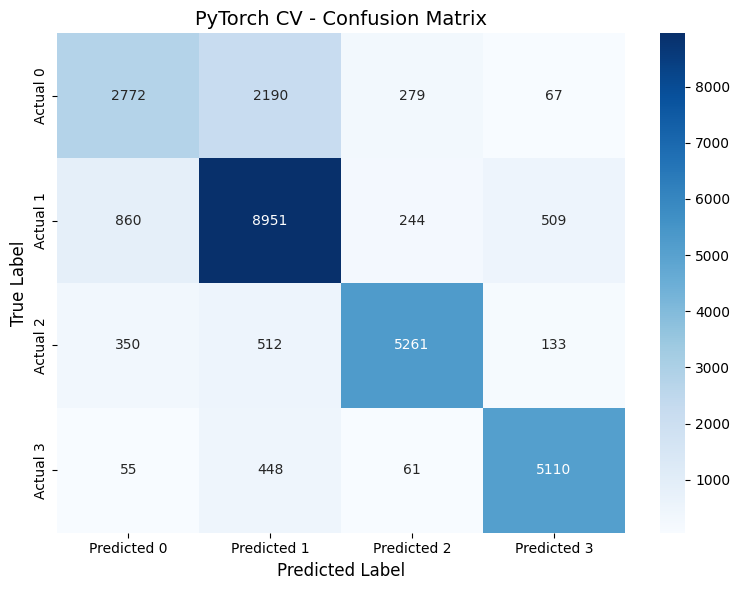

CPU times: user 4min 54s, sys: 3.56 s, total: 4min 58s
Wall time: 5min 4s


In [ ]:
%%time

rnn_metrics = cross_validate_model(
    model=rnn_model,
    X=data_nn["Text"],
    y=data_nn["Category"],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=500,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name="RNN",
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    validation_size=0.1,
    restore_best_weights=True,
)

In [93]:
rnn_metrics.to_compact_dict()

{'ROC AUC': 0.9158906585831174,
 'F1 Score': 0.776872751559064,
 'Precision': 0.7971511232433715,
 'Recall': 0.7777902360337153,
 'Accuracy': 0.7946930367076309,
 'Training Time (s)': 293.61966327699974}

In [94]:
rnn_metrics.to_dataframe()

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s)
RNN,0.915891,0.776873,0.797151,0.77779,0.794693,293.619663


In [56]:
metrics_file_name = "rnn_metrics"

save_metrics_to_csv(rnn_metrics, metrics_file_name)
# rnn_metrics = load_metrics_from_csv(metrics_file_name)

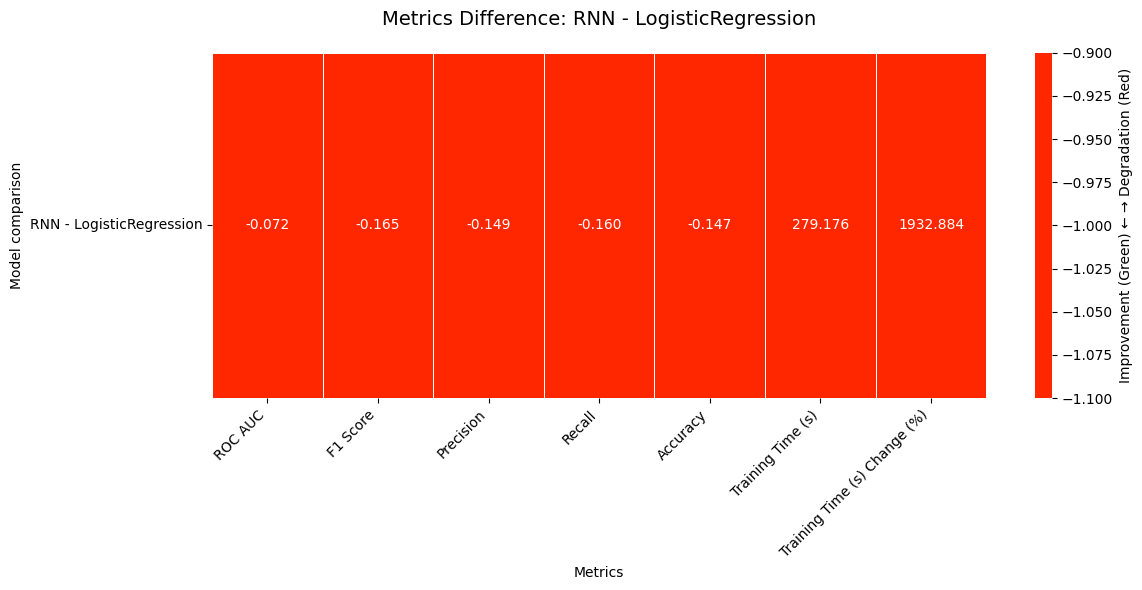

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
RNN - LogisticRegression,-0.072413,-0.164959,-0.149252,-0.159962,-0.147397,279.176162,1932.884227


In [ ]:
plot_single_model_metrics_difference_heatmap(
    baseline_metrics.to_dataframe(), rnn_metrics.to_dataframe()
)

По сравнению с baseline метрики ухудшились

In [106]:
free_memory()

## 5. CNN (Сверточная нейронная сеть)


In [113]:
BATCH_SIZE = 256
EMBEDDING_DIM = 256
FILTERS = 10
KERNEL_SIZE = 3

LEARNING_RATE = 1e-3
REGULARIZATION_STRENGTH = 1e-4

In [ ]:
cnn_model = CNNForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    num_filters=FILTERS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id,
)

cnn_model

CNNForCategoryClassification(
  (embedding): Embedding(31068, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(256, 10, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=4, bias=True)
)

In [118]:
print(f"Сверточная модель содержит число параметров: {count_parameters(cnn_model)}")

Сверточная модель содержит число параметров: 7961142


In [119]:
criterion = nn.CrossEntropyLoss()

optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}


🌀 Fold 1/3


Training fold 1:   0%|          | 1/500 [00:02<17:30,  2.11s/it]

  Epoch 1/500 | Train Loss: 1.1692 | Val Loss: 0.8783


Training fold 1:   0%|          | 2/500 [00:03<14:47,  1.78s/it]

  Epoch 2/500 | Train Loss: 0.8068 | Val Loss: 0.6746


...

  Epoch 39/500 | Train Loss: 0.0592 | Val Loss: 0.2678


Training fold 1:   8%|▊         | 40/500 [01:02<12:00,  1.57s/it]

  Epoch 40/500 | Train Loss: 0.0568 | Val Loss: 0.2706


Training fold 1:   8%|▊         | 40/500 [01:04<12:16,  1.60s/it]


  Epoch 41/500 | Train Loss: 0.0535 | Val Loss: 0.2721
  Early stopping on epoch 41 (best epoch: 31, best val loss: 0.2671)


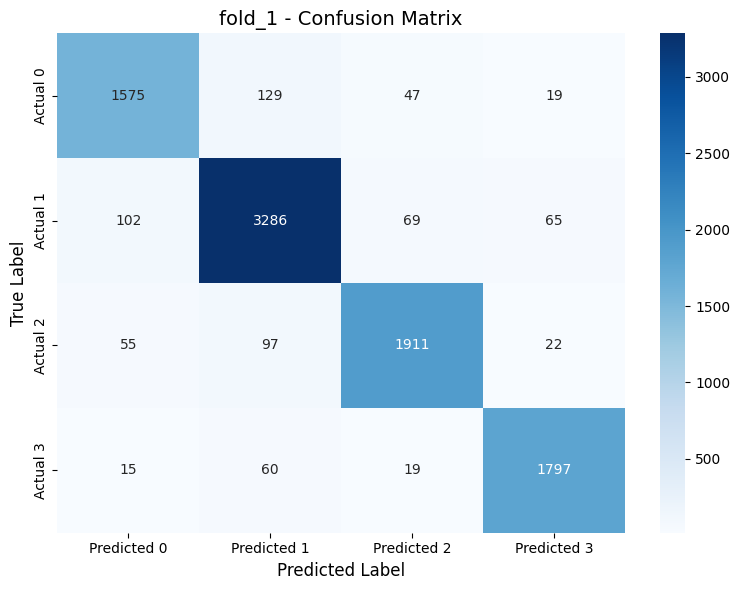


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9829
 F1 Score 0.9236
Precision 0.9249
   Recall 0.9224
 Accuracy 0.9246


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.901546 0.889831
    1   0.919933 0.932993
    2   0.934018 0.916547
    3   0.944298 0.950291


🌀 Fold 2/3


Training fold 2:   0%|          | 1/500 [00:01<13:29,  1.62s/it]

  Epoch 1/500 | Train Loss: 1.1774 | Val Loss: 0.9446


Training fold 2:   0%|          | 2/500 [00:03<13:09,  1.59s/it]

  Epoch 2/500 | Train Loss: 0.8308 | Val Loss: 0.6964


...

  Epoch 78/500 | Train Loss: 0.0172 | Val Loss: 0.2321


Training fold 2:  16%|█▌        | 79/500 [02:08<11:28,  1.64s/it]

  Epoch 79/500 | Train Loss: 0.0188 | Val Loss: 0.2363


Training fold 2:  16%|█▌        | 79/500 [02:10<11:33,  1.65s/it]


  Epoch 80/500 | Train Loss: 0.0177 | Val Loss: 0.2347
  Early stopping on epoch 80 (best epoch: 70, best val loss: 0.2268)


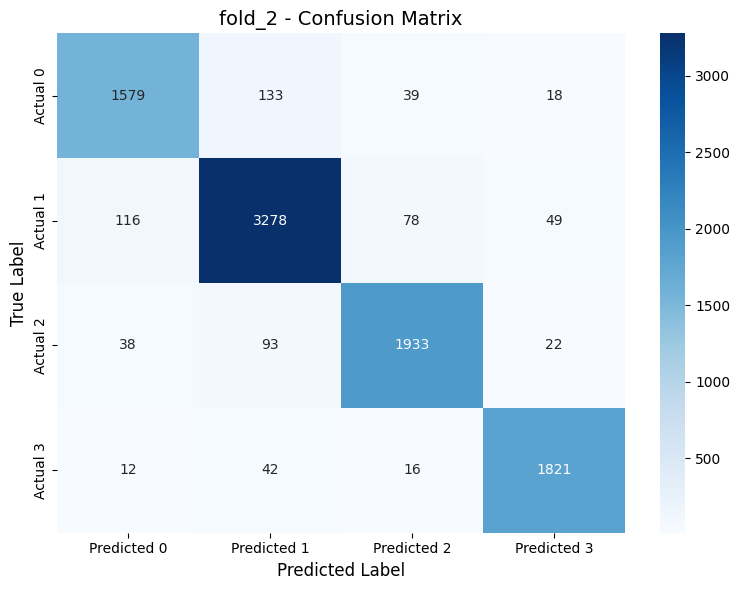


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9865
 F1 Score 0.9289
Precision 0.9296
   Recall 0.9283
 Accuracy 0.9292


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.904871 0.892595
    1   0.924422 0.930986
    2   0.935624 0.926654
    3   0.953403 0.962983


🌀 Fold 3/3


Training fold 3:   0%|          | 1/500 [00:01<14:55,  1.79s/it]

  Epoch 1/500 | Train Loss: 1.1205 | Val Loss: 0.8382


Training fold 3:   0%|          | 2/500 [00:03<14:07,  1.70s/it]

  Epoch 2/500 | Train Loss: 0.7898 | Val Loss: 0.6706


...

  Epoch 89/500 | Train Loss: 0.0139 | Val Loss: 0.2097


Training fold 3:  18%|█▊        | 90/500 [02:28<11:10,  1.64s/it]

  Epoch 90/500 | Train Loss: 0.0124 | Val Loss: 0.2129


Training fold 3:  18%|█▊        | 90/500 [02:29<11:22,  1.67s/it]


  Epoch 91/500 | Train Loss: 0.0131 | Val Loss: 0.2129
  Early stopping on epoch 91 (best epoch: 81, best val loss: 0.2074)


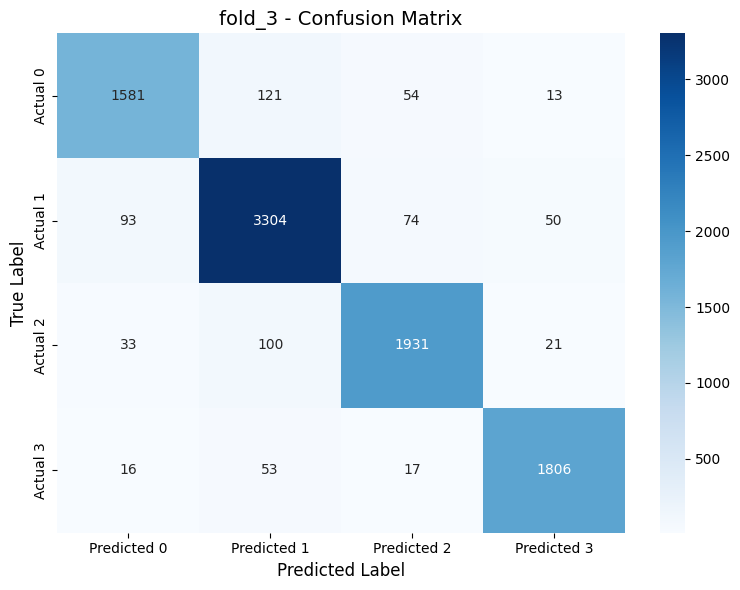


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9856
 F1 Score 0.9299
Precision 0.9317
   Recall 0.9282
 Accuracy 0.9304


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.917586 0.893725
    1   0.923421 0.938370
    2   0.930154 0.926139
    3   0.955556 0.954545



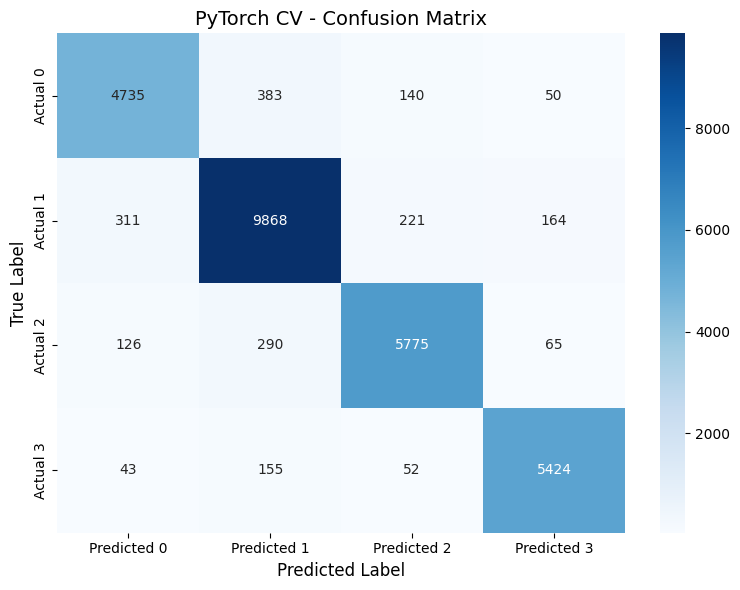

CPU times: user 5min 40s, sys: 2.98 s, total: 5min 43s
Wall time: 5min 53s


In [ ]:
%%time

cnn_metrics = cross_validate_model(
    model=cnn_model,
    X=data_nn["Text"],
    y=data_nn["Category"],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=500,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name="CNN",
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    validation_size=0.1,
    restore_best_weights=True,
)

In [121]:
cnn_metrics.to_compact_dict()

{'ROC AUC': 0.985005646386561,
 'F1 Score': 0.9274789072956761,
 'Precision': 0.9287359232679074,
 'Recall': 0.9263047472570136,
 'Accuracy': 0.9280628546024517,
 'Training Time (s)': 344.12631446900104}

In [122]:
metrics_file_name = "cnn_metrics"

save_metrics_to_csv(cnn_metrics, metrics_file_name)
# cnn_metrics = load_metrics_from_csv(metrics_file_name)

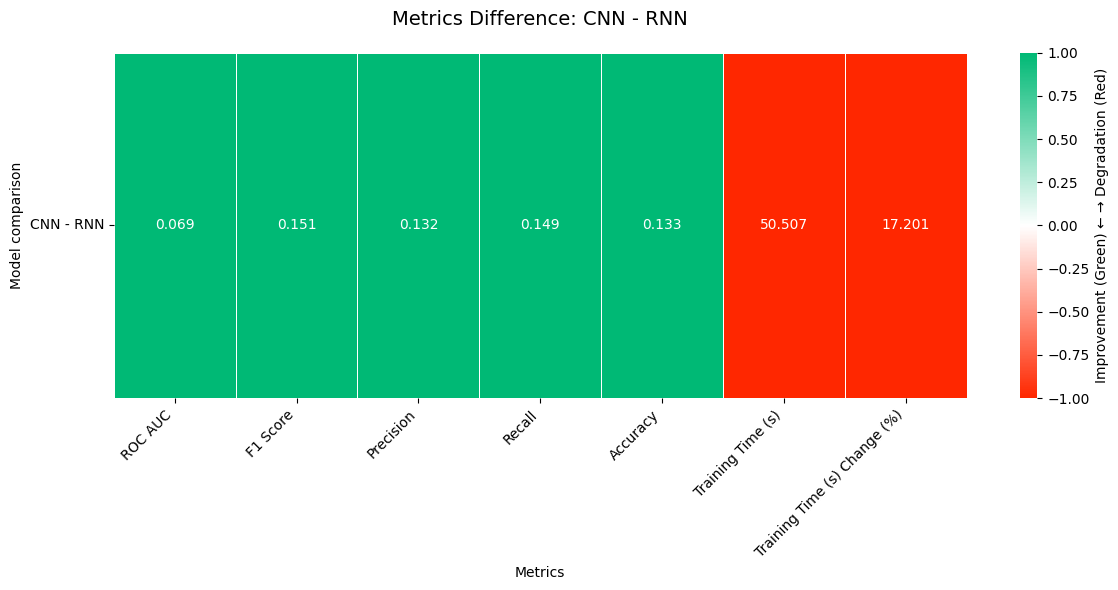

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
CNN - RNN,0.069115,0.150606,0.131585,0.148515,0.13337,50.506651,17.201386


In [ ]:
plot_single_model_metrics_difference_heatmap(
    rnn_metrics.to_dataframe(), cnn_metrics.to_dataframe()
)

Метрики CNN лучше чем у RNN

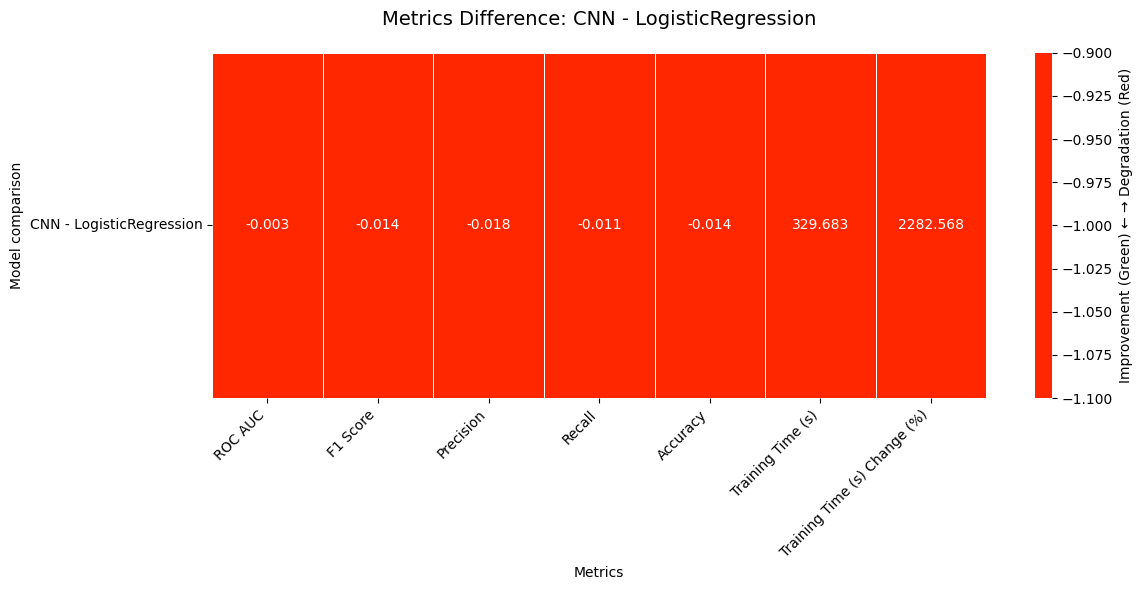

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
CNN - LogisticRegression,-0.003298,-0.014353,-0.017667,-0.011447,-0.014028,329.682813,2282.568487


In [ ]:
plot_single_model_metrics_difference_heatmap(
    baseline_metrics.to_dataframe(), cnn_metrics.to_dataframe()
)

По сравнению с baseline метрики ухудшились

In [125]:
free_memory()

## 6. LSTM (Сеть долгой краткосрочной памяти)

In [127]:
LSTM_UNITS = 64
EMBEDDING_DIM = 256
DROPOUT_RATE = 0.2
RECCURENT_DROPOUT_RATE = 0

BATCH_SIZE = 256

LEARNING_RATE = 1e-3
REGULARIZATION_STRENGTH = 1e-4

In [ ]:
lstm_model = LSTMForCategoryClassification(
    vocab_size=len(vectorizer.get_vocabulary()),
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECCURENT_DROPOUT_RATE,
    max_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_token_id=vectorizer.pad_token_id,
)

lstm_model

LSTMForCategoryClassification(
  (embedding): Embedding(31068, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [129]:
print(f"LSTM содержит число параметров: {count_parameters(lstm_model)}")

LSTM содержит число параметров: 8118788


In [130]:
criterion = nn.CrossEntropyLoss()

optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}


🌀 Fold 1/3


Training fold 1:   0%|          | 1/500 [00:01<14:12,  1.71s/it]

  Epoch 1/500 | Train Loss: 1.1227 | Val Loss: 0.8237


Training fold 1:   0%|          | 2/500 [00:03<13:18,  1.60s/it]

  Epoch 2/500 | Train Loss: 0.7761 | Val Loss: 0.6351


...

  Epoch 44/500 | Train Loss: 0.0469 | Val Loss: 0.2688


Training fold 1:   9%|▉         | 45/500 [01:14<11:59,  1.58s/it]

  Epoch 45/500 | Train Loss: 0.0457 | Val Loss: 0.2715


Training fold 1:   9%|▉         | 45/500 [01:16<12:50,  1.69s/it]


  Epoch 46/500 | Train Loss: 0.0435 | Val Loss: 0.2692
  Early stopping on epoch 46 (best epoch: 36, best val loss: 0.2648)


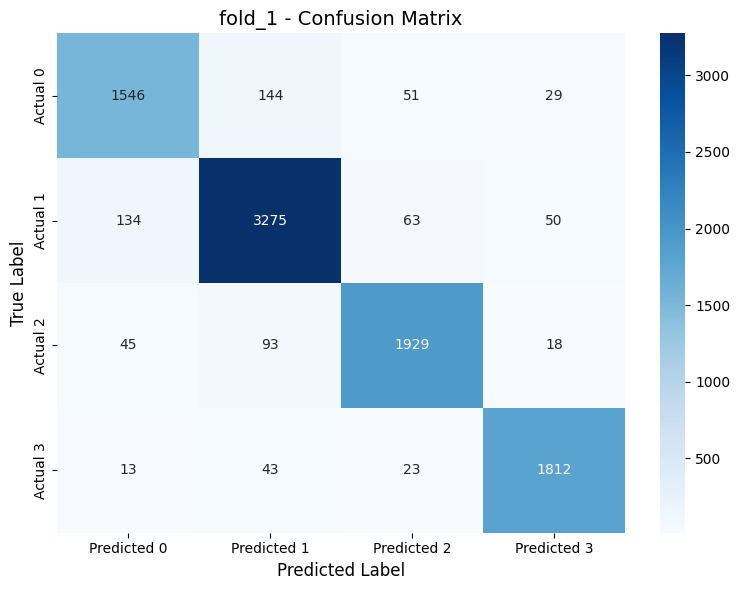


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9836
 F1 Score 0.9225
Precision 0.9234
   Recall 0.9217
 Accuracy 0.9238


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.889528 0.873446
    1   0.921238 0.929869
    2   0.933688 0.925180
    3   0.949188 0.958223


🌀 Fold 2/3


Training fold 2:   0%|          | 1/500 [00:01<13:33,  1.63s/it]

  Epoch 1/500 | Train Loss: 1.1878 | Val Loss: 0.9294


Training fold 2:   0%|          | 2/500 [00:03<13:12,  1.59s/it]

  Epoch 2/500 | Train Loss: 0.8154 | Val Loss: 0.6863


...

  Epoch 62/500 | Train Loss: 0.0256 | Val Loss: 0.2404


Training fold 2:  13%|█▎        | 63/500 [01:44<11:50,  1.63s/it]

  Epoch 63/500 | Train Loss: 0.0238 | Val Loss: 0.2401


Training fold 2:  13%|█▎        | 63/500 [01:45<12:14,  1.68s/it]


  Epoch 64/500 | Train Loss: 0.0236 | Val Loss: 0.2409
  Early stopping on epoch 64 (best epoch: 54, best val loss: 0.2397)


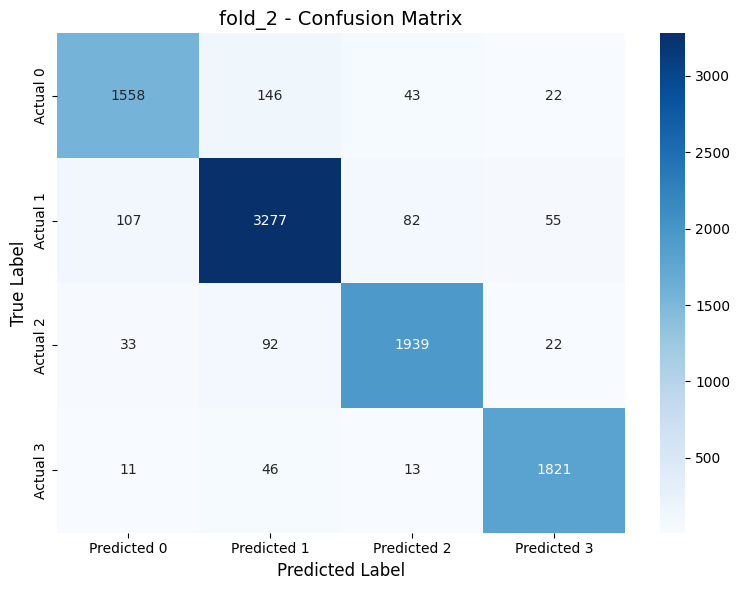


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9863
 F1 Score 0.9271
Precision 0.9285
   Recall 0.9260
 Accuracy 0.9275


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.911644 0.880724
    1   0.920247 0.930702
    2   0.933558 0.929530
    3   0.948438 0.962983


🌀 Fold 3/3


Training fold 3:   0%|          | 1/500 [00:01<14:09,  1.70s/it]

  Epoch 1/500 | Train Loss: 1.1382 | Val Loss: 0.8344


Training fold 3:   0%|          | 2/500 [00:03<13:43,  1.65s/it]

  Epoch 2/500 | Train Loss: 0.7766 | Val Loss: 0.6451


...

  Epoch 66/500 | Train Loss: 0.0200 | Val Loss: 0.2295


Training fold 3:  13%|█▎        | 67/500 [01:50<11:53,  1.65s/it]

  Epoch 67/500 | Train Loss: 0.0187 | Val Loss: 0.2282


Training fold 3:  13%|█▎        | 67/500 [01:52<12:05,  1.67s/it]


  Epoch 68/500 | Train Loss: 0.0187 | Val Loss: 0.2252
  Early stopping on epoch 68 (best epoch: 58, best val loss: 0.2211)


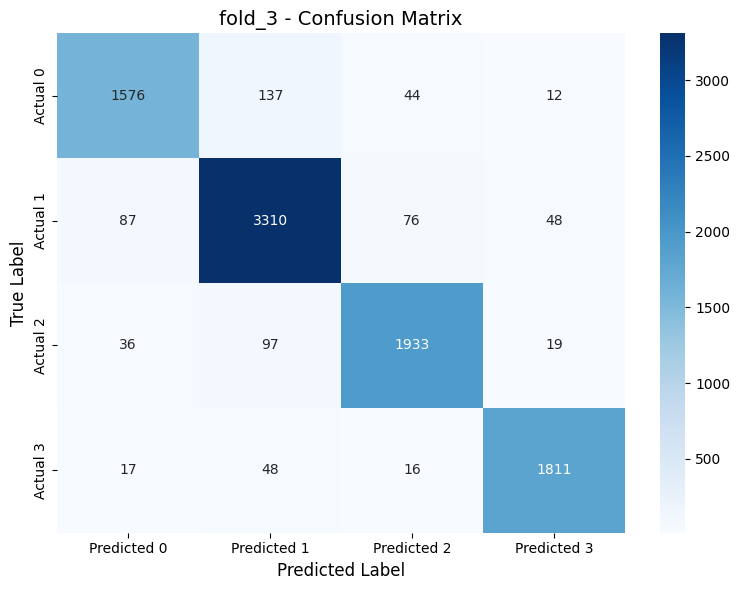


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9849
 F1 Score 0.9309
Precision 0.9331
   Recall 0.9288
 Accuracy 0.9313


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.918415 0.890899
    1   0.921492 0.940074
    2   0.934268 0.927098
    3   0.958201 0.957188



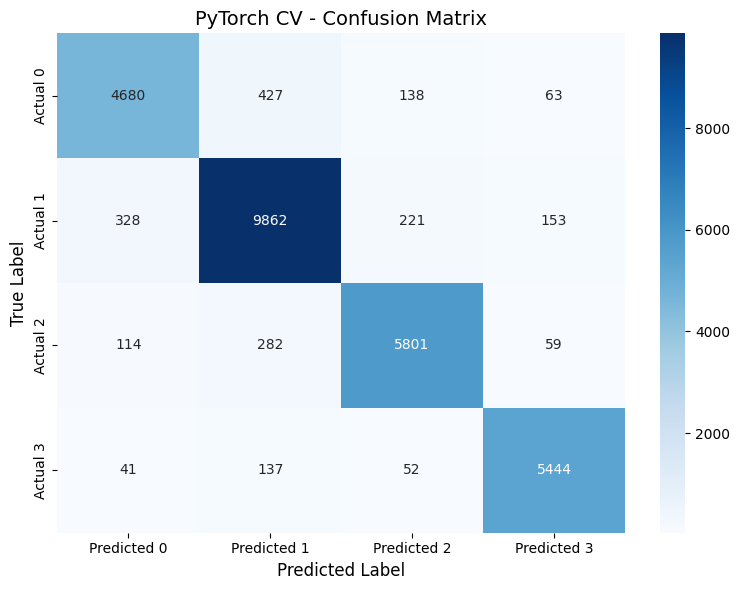

CPU times: user 4min 45s, sys: 2.53 s, total: 4min 47s
Wall time: 5min 4s


In [ ]:
%%time

lstm_metrics = cross_validate_model(
    model=cnn_model,
    X=data_nn["Text"],
    y=data_nn["Category"],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=500,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name="LSTM",
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    validation_size=0.1,
    restore_best_weights=True,
)

In [132]:
lstm_metrics.to_compact_dict()

{'ROC AUC': 0.9849455481815905,
 'F1 Score': 0.926842004581713,
 'Precision': 0.9283254206594597,
 'Recall': 0.9254929753546753,
 'Accuracy': 0.9275233328329834,
 'Training Time (s)': 294.3011795879993}

In [133]:
metrics_file_name = "lstm_metrics"

save_metrics_to_csv(lstm_metrics, metrics_file_name)
# lstm_metrics = load_metrics_from_csv(metrics_file_name)

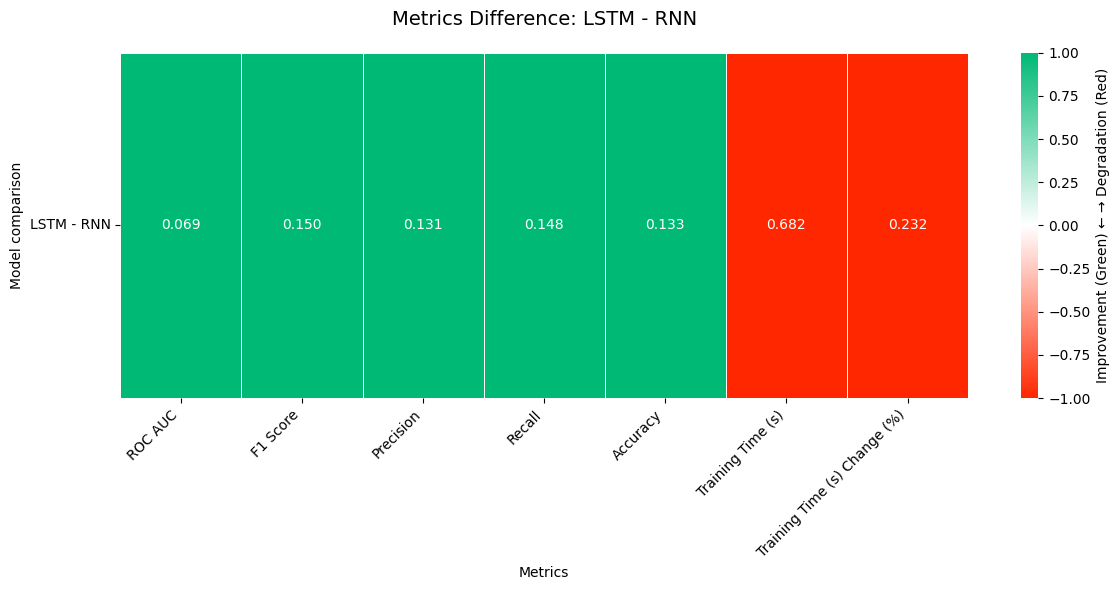

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
LSTM - RNN,0.069055,0.149969,0.131174,0.147703,0.13283,0.681516,0.232109


In [ ]:
plot_single_model_metrics_difference_heatmap(
    rnn_metrics.to_dataframe(), lstm_metrics.to_dataframe()
)

Метрики LSLM лучше чем у RNN

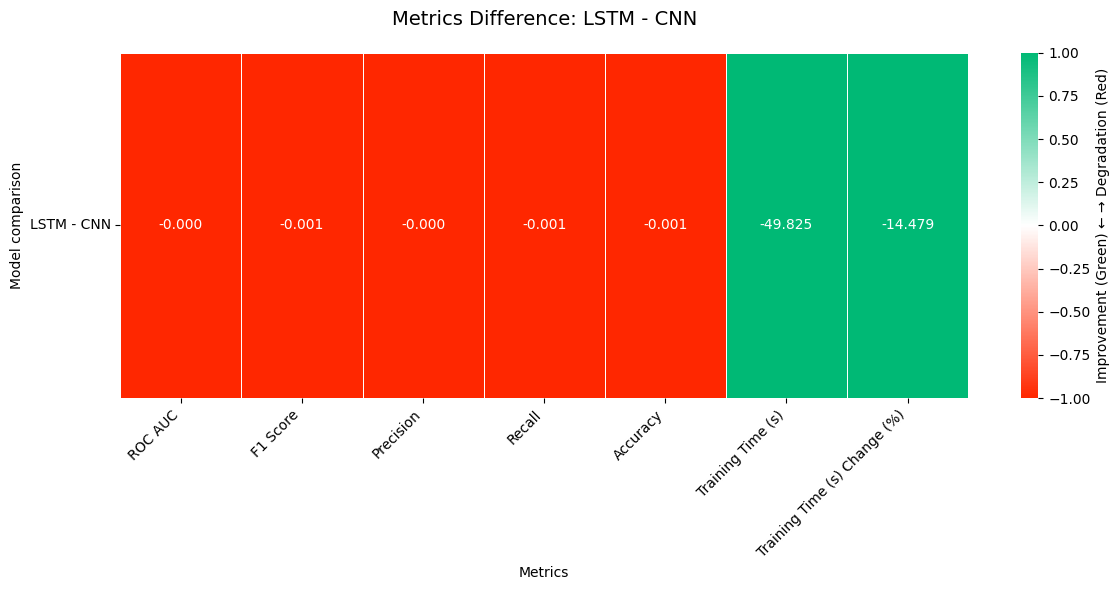

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
LSTM - CNN,-0.00006,-0.000637,-0.000411,-0.000812,-0.00054,-49.825135,-14.478734


In [ ]:
plot_single_model_metrics_difference_heatmap(
    cnn_metrics.to_dataframe(), lstm_metrics.to_dataframe()
)

Метрики LSLM чуже чем у CNN

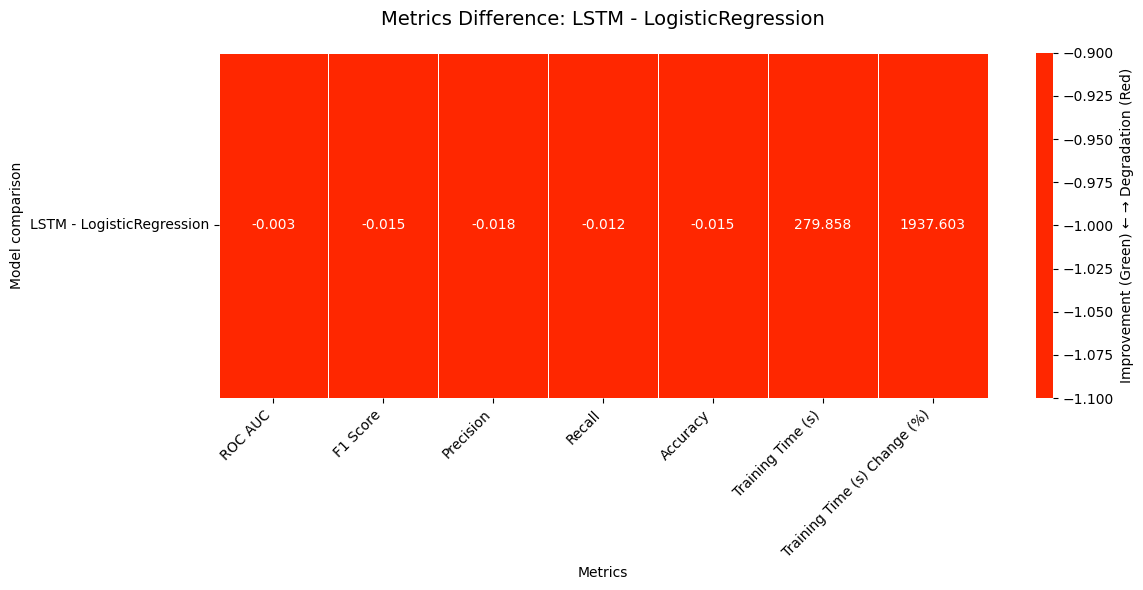

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
LSTM - LogisticRegression,-0.003359,-0.01499,-0.018077,-0.012259,-0.014567,279.857678,1937.602725


In [ ]:
plot_single_model_metrics_difference_heatmap(
    baseline_metrics.to_dataframe(), lstm_metrics.to_dataframe()
)

По сравнению с baseline метрики ухудшились

In [137]:
free_memory()

## 7. Предобученные GloVe эмбеддинги + CNN

Файл с эмбеддингами - https://huggingface.co/spaces/lwdragon/lstm_mindspore/blob/main/glove.6B.100d.txt

In [ ]:
GLOVE_DIM = 100
GLOVE_MAX_VOCAB = 20000
GLOVE_PATH: str = f"{project_path}/glove.6B.100d.txt"

In [141]:
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
FILTERS = 10
KERNEL_SIZE = 3
REGULARIZATION_STRENGTH = 1e-4
MAX_SEQUENCE_LENGTH = 500

In [ ]:
glove_vocab, glove_matrix = load_glove_fixed_vocab(
    GLOVE_PATH, GLOVE_DIM, GLOVE_MAX_VOCAB
)
glove_preprocessor = SequenceVectorizer(
    max_length=MAX_SEQUENCE_LENGTH, vocabulary=glove_vocab, pad_left=False
)
glove_preprocessor

SequenceVectorizer(max_length=500, pad_left=False,
                   vocabulary={'!': 807, '"': 10, '#': 2751, '$': 82, '%': 264,
                               '&': 1163, '&amp;': 725, "'": 59, "''": 29,
                               "'50s": 17347, "'60s": 11122, "'70s": 10964,
                               "'80s": 11320, "'90s": 11437, "'d": 1153,
                               "'em": 10806, "'ll": 771, "'m": 474, "'n": 18701,
                               "'n'": 12556, "'re": 269, "'s": 11, "'ve": 464,
                               '(': 25, '(212)': 16047, '(800)': 13105, ')': 26,
                               '*': 13699, '+': 3280, ',': 3, ...})

In [ ]:
glove_cnn_model = GloveCNNForCategoryClassification(
    glove_matrix=glove_matrix, num_filters=FILTERS, kernel_size=KERNEL_SIZE
)

glove_cnn_model

GloveCNNForCategoryClassification(
  (embedding): Embedding(20003, 100)
  (relu): ReLU()
  (conv): Conv1d(100, 10, kernel_size=(3,), stride=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=10, out_features=4, bias=True)
)

In [ ]:
print(
    f"Сверточная модель с GloVe эмбеддингами содержит число параметров: {count_parameters(glove_cnn_model)}"
)
print(
    f"Сверточная модель с GloVe эмбеддингами содержит число обучаемых параметров: {count_trainable_parameters(glove_cnn_model)}"
)

Сверточная модель с GloVe эмбеддингами содержит число параметров: 2003354
Сверточная модель с GloVe эмбеддингами содержит число обучаемых параметров: 3054


In [145]:
criterion = nn.CrossEntropyLoss()

optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}


🌀 Fold 1/3


Training fold 1:   0%|          | 1/500 [00:01<13:42,  1.65s/it]

  Epoch 1/500 | Train Loss: 1.1262 | Val Loss: 0.8345


Training fold 1:   0%|          | 2/500 [00:03<13:00,  1.57s/it]

  Epoch 2/500 | Train Loss: 0.7848 | Val Loss: 0.6602


...

  Epoch 63/500 | Train Loss: 0.0242 | Val Loss: 0.2575


Training fold 1:  13%|█▎        | 64/500 [01:40<11:31,  1.59s/it]

  Epoch 64/500 | Train Loss: 0.0246 | Val Loss: 0.2521


Training fold 1:  13%|█▎        | 64/500 [01:42<11:38,  1.60s/it]


  Epoch 65/500 | Train Loss: 0.0233 | Val Loss: 0.2540
  Early stopping on epoch 65 (best epoch: 55, best val loss: 0.2502)


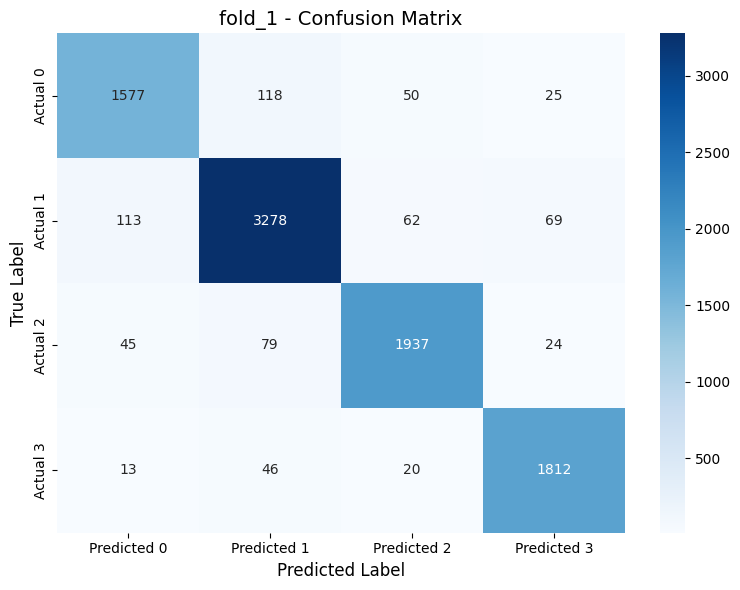


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9849
 F1 Score 0.9271
Precision 0.9271
   Recall 0.9272
 Accuracy 0.9284


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.902174 0.890960
    1   0.930986 0.930721
    2   0.936201 0.929017
    3   0.938860 0.958223


🌀 Fold 2/3


Training fold 2:   0%|          | 1/500 [00:01<13:35,  1.63s/it]

  Epoch 1/500 | Train Loss: 1.1708 | Val Loss: 0.8934


Training fold 2:   0%|          | 2/500 [00:03<13:22,  1.61s/it]

  Epoch 2/500 | Train Loss: 0.7922 | Val Loss: 0.6668


...

  Epoch 46/500 | Train Loss: 0.0429 | Val Loss: 0.2514


Training fold 2:   9%|▉         | 47/500 [01:17<12:47,  1.69s/it]

  Epoch 47/500 | Train Loss: 0.0417 | Val Loss: 0.2465


Training fold 2:   9%|▉         | 47/500 [01:19<12:43,  1.69s/it]


  Epoch 48/500 | Train Loss: 0.0396 | Val Loss: 0.2501
  Early stopping on epoch 48 (best epoch: 38, best val loss: 0.2436)


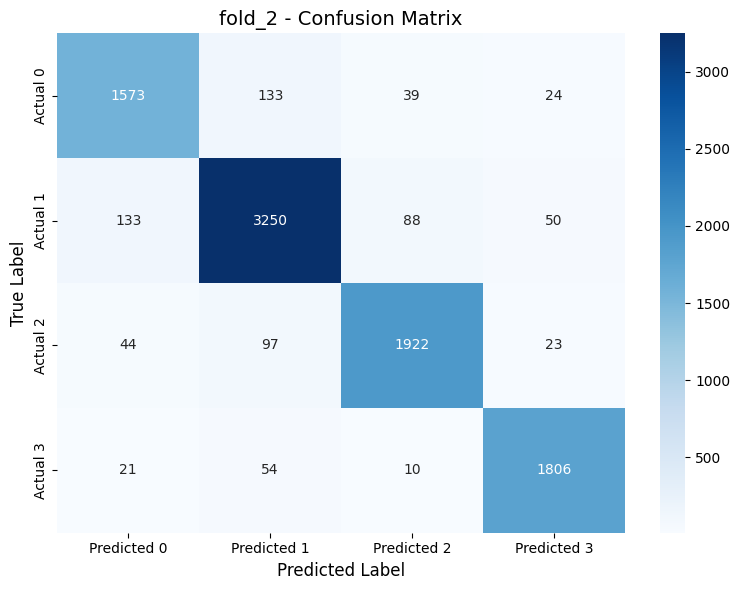


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9854
 F1 Score 0.9224
Precision 0.9226
   Recall 0.9222
 Accuracy 0.9227


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.888199 0.889203
    1   0.919638 0.923033
    2   0.933463 0.921381
    3   0.949028 0.955050


🌀 Fold 3/3


Training fold 3:   0%|          | 1/500 [00:01<14:01,  1.69s/it]

  Epoch 1/500 | Train Loss: 1.1080 | Val Loss: 0.7972


Training fold 3:   0%|          | 2/500 [00:03<14:05,  1.70s/it]

  Epoch 2/500 | Train Loss: 0.7445 | Val Loss: 0.6142


...

  Epoch 76/500 | Train Loss: 0.0149 | Val Loss: 0.2013


Training fold 3:  15%|█▌        | 77/500 [02:09<12:10,  1.73s/it]

  Epoch 77/500 | Train Loss: 0.0148 | Val Loss: 0.1991


Training fold 3:  15%|█▌        | 77/500 [02:10<11:59,  1.70s/it]


  Epoch 78/500 | Train Loss: 0.0140 | Val Loss: 0.1993
  Early stopping on epoch 78 (best epoch: 68, best val loss: 0.1919)


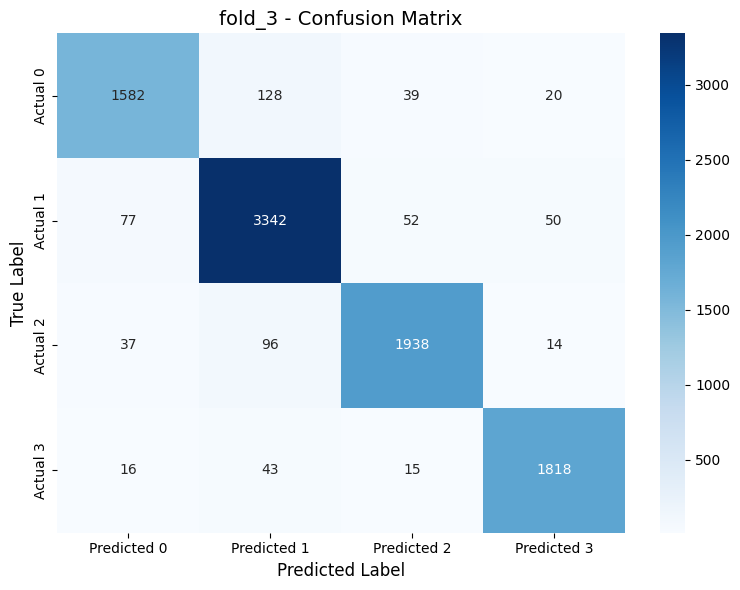


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9870
 F1 Score 0.9359
Precision 0.9385
   Recall 0.9335
 Accuracy 0.9367


CLASSIFICATION REPORT:
Class  Precision   Recall
    0   0.924065 0.894291
    1   0.926018 0.949162
    2   0.948141 0.929496
    3   0.955836 0.960888



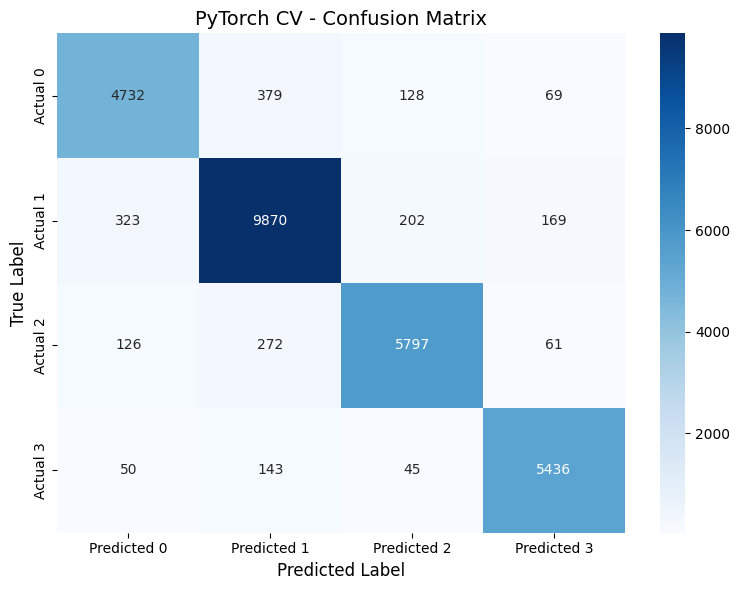

CPU times: user 5min 10s, sys: 4.29 s, total: 5min 14s
Wall time: 5min 23s


In [ ]:
%%time

glove_cnn_metrics = cross_validate_model(
    model=cnn_model,
    X=data_nn["Text"],
    y=data_nn["Category"],
    preprocessor=basic_preprocessor,
    cv=cv,
    criterion=criterion,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=500,
    batch_size=BATCH_SIZE,
    enable_plot=True,
    model_name="CNN with GloVe",
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    validation_size=0.1,
    restore_best_weights=True,
)

In [147]:
glove_cnn_metrics.to_compact_dict()

{'ROC AUC': 0.9857491997862287,
 'F1 Score': 0.9284442682077868,
 'Precision': 0.9293840353946689,
 'Recall': 0.9276188085938925,
 'Accuracy': 0.9292497264259456,
 'Training Time (s)': 312.7049041070004}

In [148]:
metrics_file_name = "glove_cnn_metrics"

save_metrics_to_csv(glove_cnn_metrics, metrics_file_name)
# glove_cnn_metrics = load_metrics_from_csv(metrics_file_name)

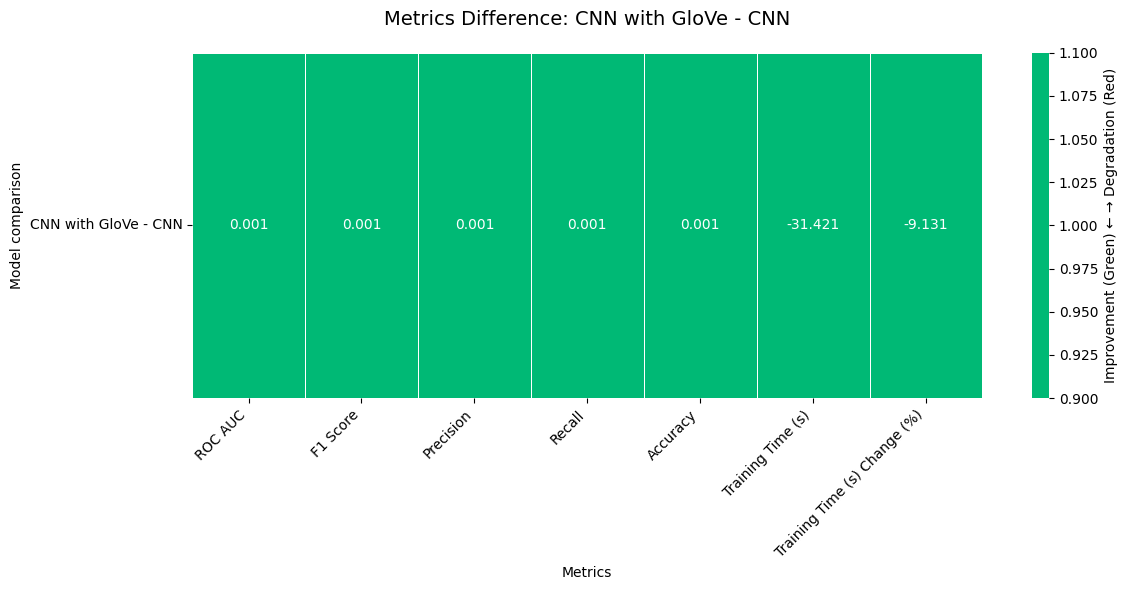

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
CNN with GloVe - CNN,0.000744,0.000965,0.000648,0.001314,0.001187,-31.42141,-9.130778


In [ ]:
plot_single_model_metrics_difference_heatmap(
    cnn_metrics.to_dataframe(), glove_cnn_metrics.to_dataframe()
)

Метрики у CNN с предобученными эмбеддингами от GLOVE лучше чем у обычной CNN

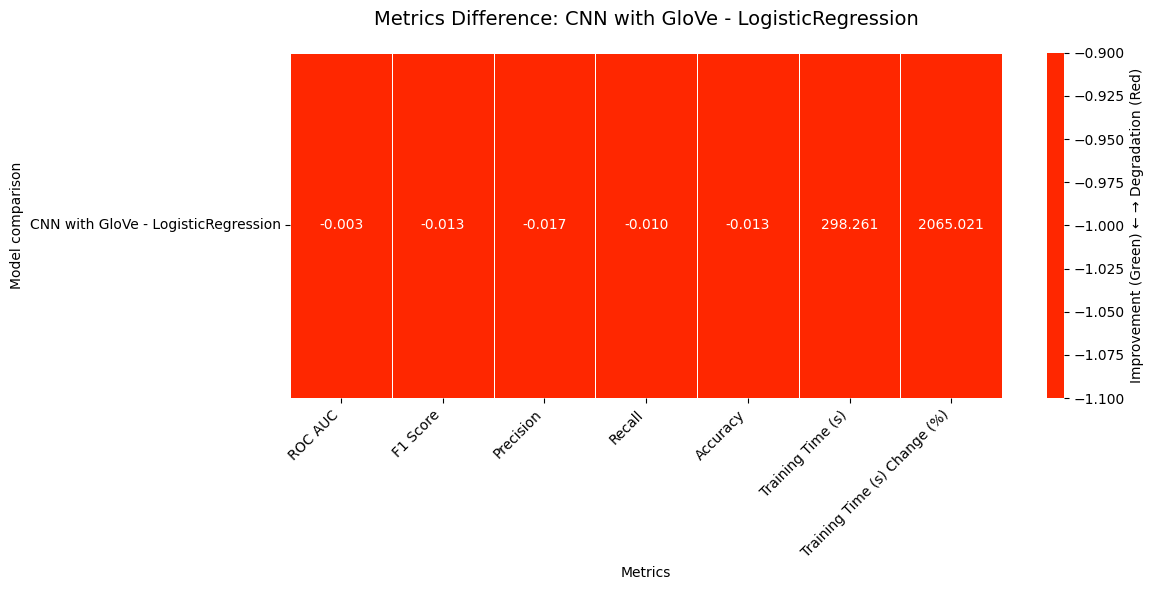

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
CNN with GloVe - LogisticRegression,-0.002555,-0.013388,-0.017019,-0.010133,-0.012841,298.261403,2065.021444


In [ ]:
plot_single_model_metrics_difference_heatmap(
    baseline_metrics.to_dataframe(), glove_cnn_metrics.to_dataframe()
)

По сравнению с baseline метрики ухудшились

In [151]:
free_memory()

## 8. Замороженные BERT эмбеддинги + Linear

In [ ]:
df_preprocessed_transformer = df.copy()

df_preprocessed_transformer = df_preprocessed_transformer.drop_duplicates().reset_index(
    drop=True
)
df_preprocessed_transformer = df_preprocessed_transformer.dropna().reset_index(
    drop=True
)

category_dict = {
    "Electronics": 0,
    "Household": 1,
    "Books": 2,
    "Clothing & Accessories": 3,
}

df_preprocessed_transformer["Category"] = df_preprocessed_transformer[
    "Category"
].replace(category_dict)

# Для BERT / RoBERTa / DeBERTa текст оставляем как обычную строку
df_preprocessed_transformer["Text"] = df_preprocessed_transformer["Text"].astype(str)

/tmp/ipykernel_1040/359606410.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_preprocessed_transformer["Category"] = df_preprocessed_transformer["Category"].replace(category_dict)


In [ ]:
# MODEL_NAME = "microsoft/deberta-v3-base"
MODEL_NAME = "microsoft/MiniLM-L12-H384-uncased"
# MODEL_NAME = "google/mobilebert-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bert_model = BertTextClassifier(
    model_name=MODEL_NAME, num_labels=4, freeze_encoder=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [207]:
LEARNING_RATE = 2e-5
BATCH_SIZE = 256
REGULARIZATION_STRENGTH = 0.01
MAX_SEQUENCE_LENGTH = 128

In [208]:
optimizer_class = optim.Adam
optimizer_params = {"lr": LEARNING_RATE, "weight_decay": REGULARIZATION_STRENGTH}

Так как обучение BERT занимает очень много времени я остановлю его раньше. Из за этого метрики BERT будут скорее всего намного хуже чем у остальных моделей


Fold 1/3


Training fold 1:  20%|██        | 1/5 [00:50<03:21, 50.38s/it]

Epoch 1/5 | Train Loss: 1.3774 | Val Loss: 1.3724


Training fold 1:  40%|████      | 2/5 [01:39<02:28, 49.59s/it]

Epoch 2/5 | Train Loss: 1.3712 | Val Loss: 1.3659


...

Epoch 3/5 | Train Loss: 1.3655 | Val Loss: 1.3606


Training fold 1:  80%|████████  | 4/5 [03:27<00:53, 53.20s/it]

Epoch 4/5 | Train Loss: 1.3612 | Val Loss: 1.3560


Training fold 1: 100%|██████████| 5/5 [04:19<00:00, 51.99s/it]


Epoch 5/5 | Train Loss: 1.3573 | Val Loss: 1.3522


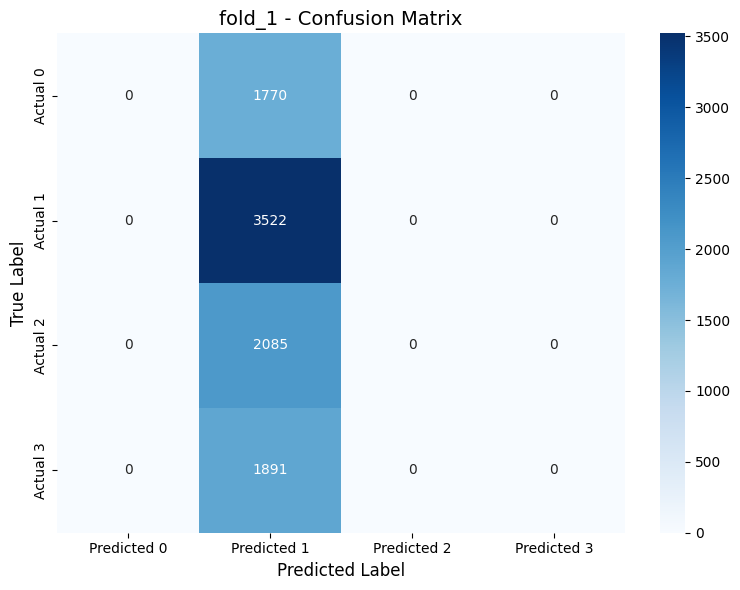


                     FOLD_1 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.5179
 F1 Score 0.1377
Precision 0.0950
   Recall 0.2500
 Accuracy 0.3800


CLASSIFICATION REPORT:
Class  Precision  Recall
    0   0.000000     0.0
    1   0.380017     1.0
    2   0.000000     0.0
    3   0.000000     0.0


Fold 2/3


Training fold 2:  20%|██        | 1/5 [00:54<03:36, 54.01s/it]

Epoch 1/5 | Train Loss: 1.3778 | Val Loss: 1.3725


Training fold 2:  40%|████      | 2/5 [01:48<02:43, 54.41s/it]

Epoch 2/5 | Train Loss: 1.3714 | Val Loss: 1.3660


...

Epoch 3/5 | Train Loss: 1.3662 | Val Loss: 1.3604


Training fold 2:  80%|████████  | 4/5 [03:36<00:54, 54.03s/it]

Epoch 4/5 | Train Loss: 1.3616 | Val Loss: 1.3556


Training fold 2: 100%|██████████| 5/5 [04:27<00:00, 53.52s/it]


Epoch 5/5 | Train Loss: 1.3573 | Val Loss: 1.3518


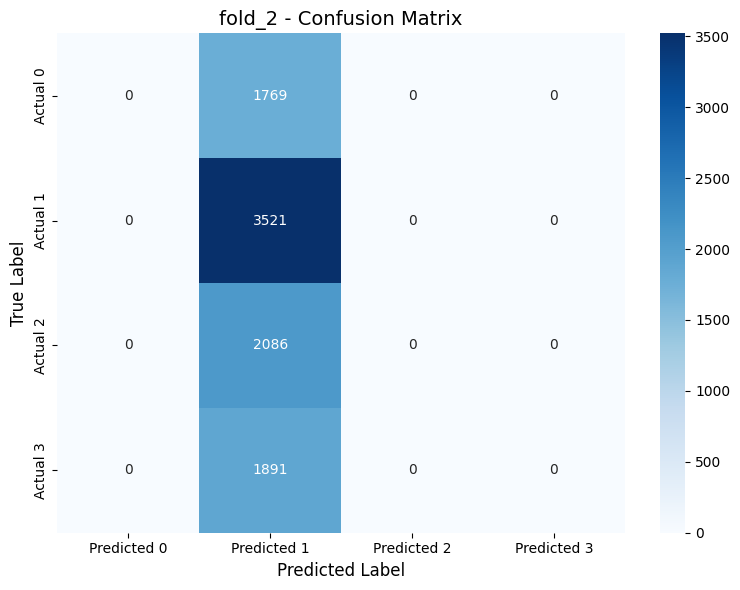


                     FOLD_2 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.5172
 F1 Score 0.1377
Precision 0.0950
   Recall 0.2500
 Accuracy 0.3800


CLASSIFICATION REPORT:
Class  Precision  Recall
    0    0.00000     0.0
    1    0.37995     1.0
    2    0.00000     0.0
    3    0.00000     0.0


Fold 3/3


Training fold 3:  20%|██        | 1/5 [00:51<03:26, 51.64s/it]

Epoch 1/5 | Train Loss: 1.3777 | Val Loss: 1.3725


Training fold 3:  40%|████      | 2/5 [01:45<02:38, 52.77s/it]

Epoch 2/5 | Train Loss: 1.3714 | Val Loss: 1.3661


...

Epoch 3/5 | Train Loss: 1.3663 | Val Loss: 1.3605


Training fold 3:  80%|████████  | 4/5 [03:25<00:51, 51.09s/it]

Epoch 4/5 | Train Loss: 1.3616 | Val Loss: 1.3558


Training fold 3: 100%|██████████| 5/5 [04:16<00:00, 51.32s/it]


Epoch 5/5 | Train Loss: 1.3574 | Val Loss: 1.3518


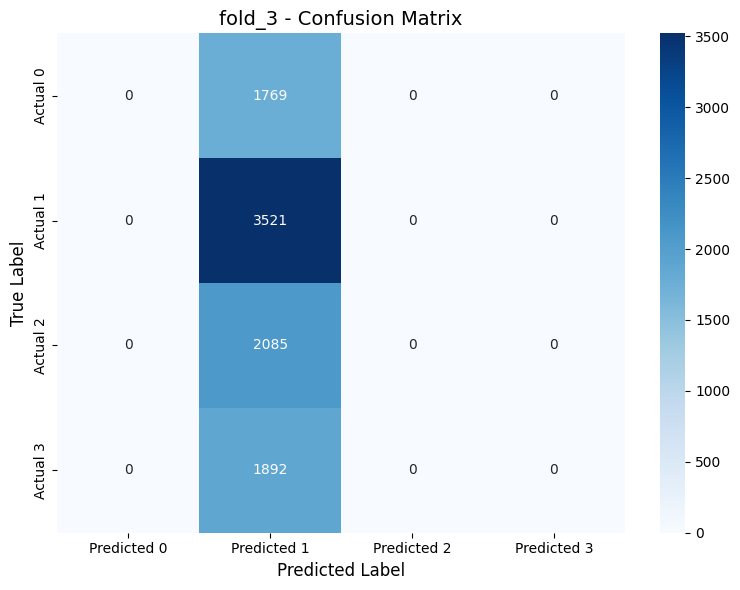


                     FOLD_3 EVALUATION                      

MAIN METRICS:
   Metric  Value
  ROC AUC 0.5224
 F1 Score 0.1377
Precision 0.0950
   Recall 0.2500
 Accuracy 0.3800


CLASSIFICATION REPORT:
Class  Precision  Recall
    0    0.00000     0.0
    1    0.37995     1.0
    2    0.00000     0.0
    3    0.00000     0.0



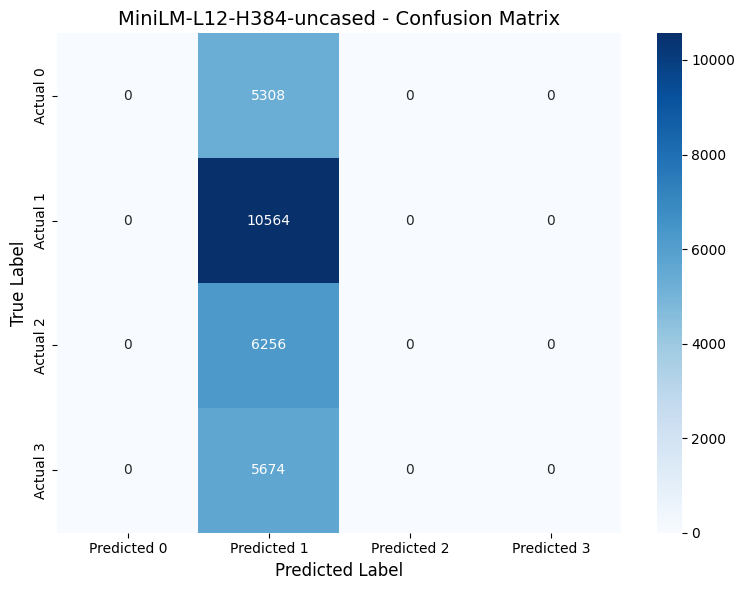

In [ ]:
bert_metrics = cross_validate_transformer_model(
    model=bert_model,
    tokenizer=tokenizer,
    X=df_preprocessed_transformer["Text"].values,
    y=df_preprocessed_transformer["Category"].values,
    cv=cv,
    optimizer_class=optimizer_class,
    optimizer_params=optimizer_params,
    num_epochs=5,
    batch_size=BATCH_SIZE,
    max_length=MAX_SEQUENCE_LENGTH,
    enable_plot=True,
    model_name="MiniLM-L12-H384-uncased",
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    validation_size=0.1,
    restore_best_weights=True,
)

In [210]:
bert_metrics.to_compact_dict()

{'ROC AUC': 0.5191897131437895,
 'F1 Score': 0.13767398156125812,
 'Precision': 0.09499316555822,
 'Recall': 0.25,
 'Accuracy': 0.37997266223288,
 'Training Time (s)': 784.3379254659994}

In [211]:
metrics_file_name = "bert_metrics"

save_metrics_to_csv(bert_metrics, metrics_file_name)
# bert_metrics = load_metrics_from_csv(metrics_file_name)

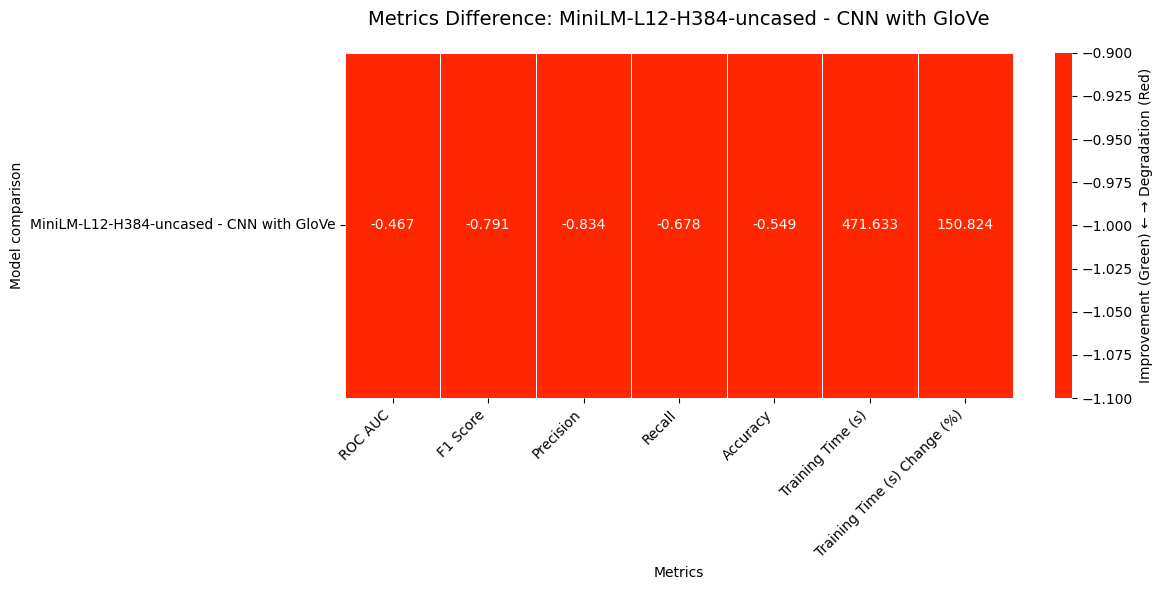

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
MiniLM-L12-H384-uncased - CNN with GloVe,-0.466559,-0.79077,-0.834391,-0.677619,-0.549277,471.633021,150.823673


In [ ]:
plot_single_model_metrics_difference_heatmap(
    glove_cnn_metrics.to_dataframe(), bert_metrics.to_dataframe()
)

Метрики у CNN с предобученными эмбеддингами от GLOVE лучше чем у BERT, так как скорее всего он не дообучился

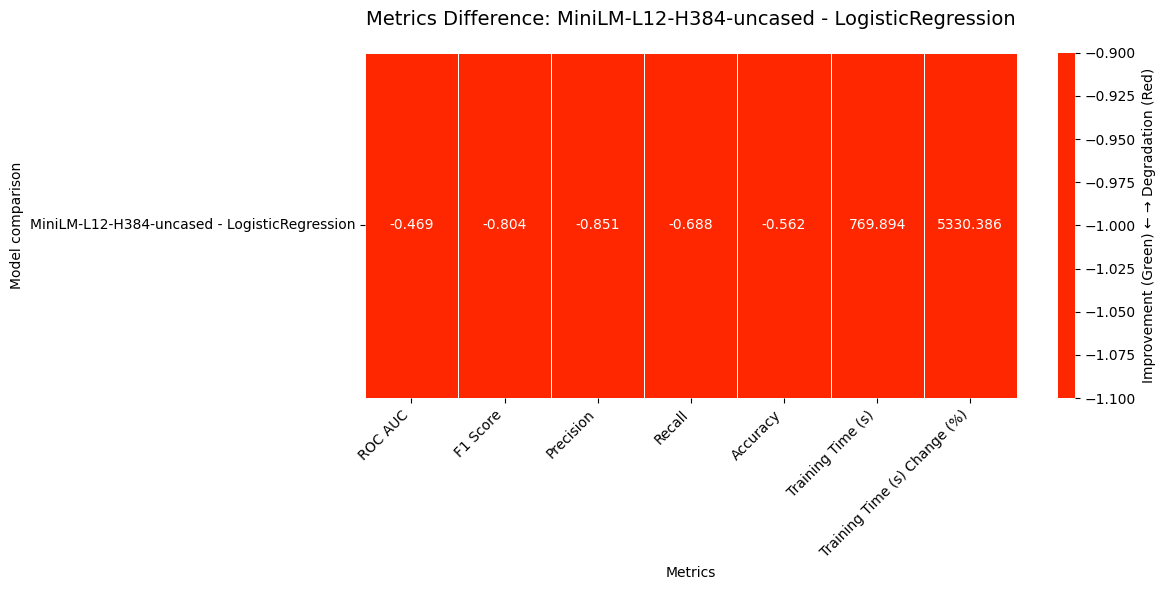

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
MiniLM-L12-H384-uncased - LogisticRegression,-0.469114,-0.804158,-0.85141,-0.687752,-0.562118,769.894424,5330.386302


In [ ]:
plot_single_model_metrics_difference_heatmap(
    baseline_metrics.to_dataframe(), bert_metrics.to_dataframe()
)

По сравнению с baseline метрики ухудшились

In [204]:
free_memory()

## 9. Сравнение качества полученных моделей

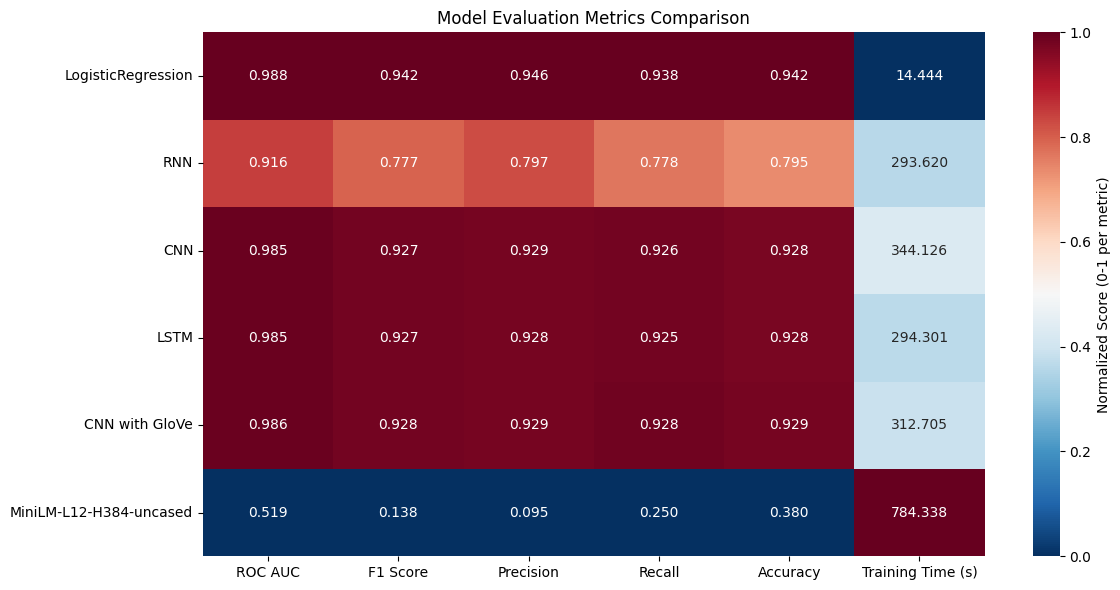

In [ ]:
plot_metrics_heatmap(
    [
        baseline_metrics,
        rnn_metrics,
        cnn_metrics,
        lstm_metrics,
        glove_cnn_metrics,
        bert_metrics,
    ]
)

Самые лучшие метрики показала `Логистическая регрессия` + `TfidfVectorizer`. Затем идет CNN с предобученными эмбеддингами от GLOVE

Так как обучение BERT занимает очень много времени я остановил его раньше. Из за этого метрики BERT оказались намного хуже чем у остальных моделей.

Не считая BERT, хуже всего показала себя `RNN`